# Isotropic minimal PSF for Euclid VIS

Builds `euclid_vis_isotropic_min_psf.fits`, the reference PSF used for the `psf_residual` column
of the dataset. It is an isotropic PSF whose Fourier amplitude is at least that of the PSFs of the
whole VIS focal plane (up to a 0.15 % deficit at 48 of the 11,664 positions), so that the residual
kernel `FT(PSF) / FT(reference)` stays bounded, and whose FWHM is below the smallest one of the field.

**Input**: the global VIS PSF model `EUC_VIS_GRD-PSF-*.fits` (downloaded by `sync_psf_model`),
placed next to this notebook. It has 144 extensions (6 × 6 CCDs × 4 quadrants `E`–`H`), and each
189 × 189 quadrant image is a 9 × 9 mosaic of 21 × 21 PSF stamps: 11,664 PSFs sampled at 0.1″/px.

**Method**

1. extract the 11,664 PSFs and normalise their flux;
2. take the pointwise maximum of their FFT amplitudes (envelope);
3. make the envelope isotropic: pointwise maximum over continuous rotations;
4. find a positive image with at least this amplitude, by alternating projections;
5. check Fourier dominance, FWHM and isotropy of the result.

The output is written next to this notebook; copy it to `src/` to use it in the pipeline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import galsim
import re
from scipy.ndimage import rotate as ndi_rotate

%matplotlib inline

fits_path = 'EUC_VIS_GRD-PSF-000-000000-0000000__20240322T192915.424564Z.fits'
pixel_scale = 0.1          # arcsec/px, native VIS sampling (CD1_1, OVERSAMP=1)
n_sub = 9                  # 9x9 PSF grid per quadrant
output_dir = '.'
output_stamp_size = 21     # side (px) of the comparison stamp of step 10
n_rotation_steps = 360     # continuous rotation steps for the isotropisation (1 deg/step)


def safe_log10(img, floor=1e-6):
    """log10 with a floor, for display."""
    return np.log10(np.clip(img, floor, None))

## 1. Open the FITS file and list the quadrants

In [2]:
hdul = fits.open(fits_path)

pattern = re.compile(r'^(\d+)-(\d+)\.([A-Z])$')
quadrant_records = []
for i, hdu in enumerate(hdul[1:]):
    name = hdu.header['EXTNAME'].strip()
    m = pattern.match(name)
    quadrant_records.append(dict(ext_index=i, name=name,
                                  ccd_row=int(m.group(1)), ccd_col=int(m.group(2)), quadrant=m.group(3)))

n_quadrants = len(quadrant_records)
quadrant_size = hdul[1].data.shape[0]

print(f"{n_quadrants} quadrant images, each {hdul[1].data.shape}")
print(f"pixel_scale (header CD1_1): {hdul[1].header['CD1_1']*3600:.4f} arcsec/pixel, "
      f"OVERSAMP={hdul[1].header['OVERSAMP']}")

144 quadrant images, each (189, 189)
pixel_scale (header CD1_1): 0.1000 arcsec/pixel, OVERSAMP=1.0


## 2. Check the 9 × 9 grid of a quadrant

The flux profile summed along one axis must show 9 evenly spaced peaks.

Peak positions: [np.int64(10), np.int64(31), np.int64(52), np.int64(73), np.int64(94), np.int64(115), np.int64(136), np.int64(157), np.int64(178)]
Spacing (should be 21): [21 21 21 21 21 21 21 21]


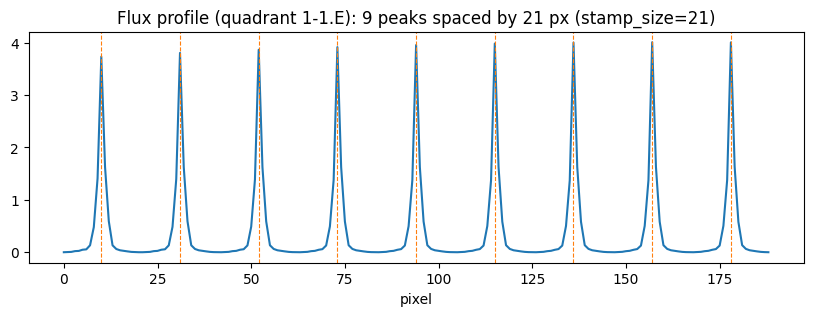

In [3]:
example = hdul[1].data.astype(np.float64)
stamp_size = quadrant_size // n_sub
row_profile = example.sum(axis=0)

peak_positions = [b * stamp_size + np.argmax(row_profile[b * stamp_size:(b + 1) * stamp_size])
                  for b in range(n_sub)]

plt.figure(figsize=(10, 3))
plt.plot(row_profile)
for p in peak_positions:
    plt.axvline(p, color='C1', lw=0.8, ls='--')
plt.title(f"Flux profile (quadrant {quadrant_records[0]['name']}): 9 peaks spaced by "
          f"{np.diff(peak_positions)[0]} px (stamp_size={stamp_size})")
plt.xlabel('pixel')

print(f"Peak positions: {peak_positions}")
print(f"Spacing (should be {stamp_size}): {np.diff(peak_positions)}")

## 3. Extract the 144 × 81 = 11,664 PSFs and normalise their flux

Individual PSFs: 11664 (144 quadrants x 9x9)
Stamp shape: (21, 21)
Raw flux before normalisation (fraction inside the 21x21 stamp): min=0.905, max=1.008


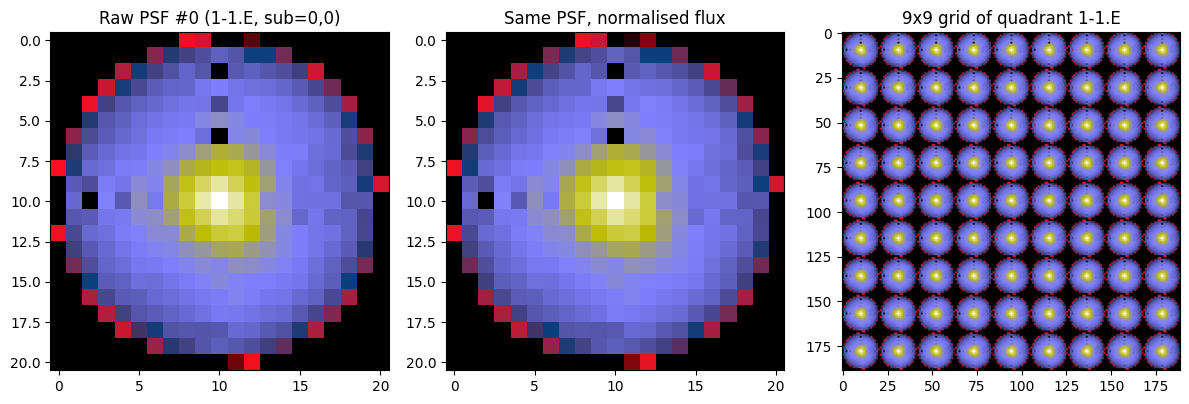

In [4]:
all_stamps = []
all_records = []
for r in quadrant_records:
    data = hdul[1:][r['ext_index']].data.astype(np.float64)
    sub = data.reshape(n_sub, stamp_size, n_sub, stamp_size).transpose(0, 2, 1, 3)
    for sub_row in range(n_sub):
        for sub_col in range(n_sub):
            all_stamps.append(sub[sub_row, sub_col])
            all_records.append(dict(**r, sub_row=sub_row, sub_col=sub_col))

stamps_raw = np.stack(all_stamps)
n_positions = len(stamps_raw)
flux_sums = stamps_raw.sum(axis=(1, 2))
stamps = stamps_raw / flux_sums[:, None, None]

print(f"Individual PSFs: {n_positions} ({n_quadrants} quadrants x {n_sub}x{n_sub})")
print(f"Stamp shape: {stamps.shape[1:]}")
print(f"Raw flux before normalisation (fraction inside the 21x21 stamp): "
      f"min={flux_sums.min():.3f}, max={flux_sums.max():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(safe_log10(stamps_raw[0]), cmap='gist_stern')
axes[0].set_title(f"Raw PSF #0 ({all_records[0]['name']}, sub={all_records[0]['sub_row']},"
                   f"{all_records[0]['sub_col']})")
axes[1].imshow(safe_log10(stamps[0]), cmap='gist_stern')
axes[1].set_title('Same PSF, normalised flux')
quadrant_mosaic = stamps[:n_sub * n_sub].reshape(n_sub, n_sub, stamp_size, stamp_size) \
    .transpose(0, 2, 1, 3).reshape(n_sub * stamp_size, n_sub * stamp_size)
axes[2].imshow(safe_log10(quadrant_mosaic), cmap='gist_stern')
axes[2].set_title(f"9x9 grid of quadrant {all_records[0]['name']}")
plt.tight_layout()

## 4. FWHM across the field

FWHM min=0.1415 arcsec, max=0.1572 arcsec, mean=0.1515 arcsec


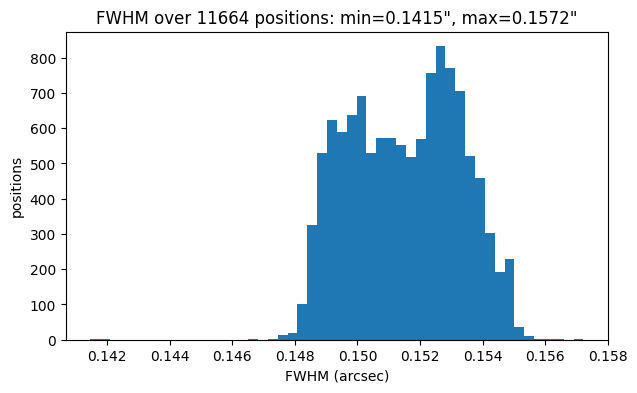

In [5]:
fwhms = np.array([
    galsim.InterpolatedImage(galsim.Image(stamps[i], scale=pixel_scale), flux=1.).calculateFWHM()
    for i in range(n_positions)
])

plt.figure(figsize=(7, 4))
plt.hist(fwhms, bins=50)
plt.xlabel('FWHM (arcsec)')
plt.ylabel('positions')
plt.title(f"FWHM over {n_positions} positions: min={fwhms.min():.4f}\", max={fwhms.max():.4f}\"")
print(f"FWHM min={fwhms.min():.4f} arcsec, max={fwhms.max():.4f} arcsec, "
      f"mean={fwhms.mean():.4f} arcsec")

## 5. Fourier amplitudes with GalSim

Continuous Fourier transform of each PSF, only used for the independent check of step 12.

k-space cube: (11664, 21, 21)


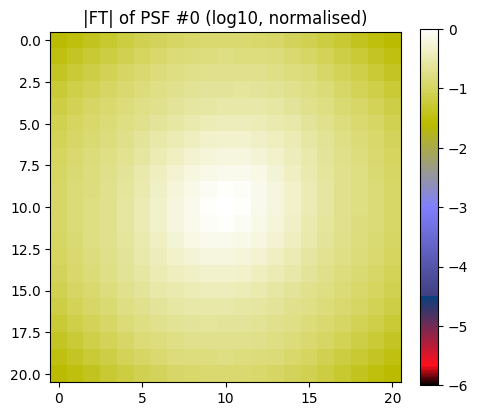

In [6]:
kscale = 2. * np.pi / (pixel_scale * stamp_size)

ims_k = np.array([
    np.abs(galsim.InterpolatedImage(galsim.Image(stamps[i], scale=pixel_scale), flux=1.)
           .drawKImage(nx=stamp_size, ny=stamp_size, scale=kscale).array)
    for i in range(n_positions)
])

print(f"k-space cube: {ims_k.shape}")
plt.figure(figsize=(5, 5))
plt.imshow(safe_log10(ims_k[0] / ims_k[0].max()), cmap='gist_stern', vmax=0, vmin=-6)
plt.title('|FT| of PSF #0 (log10, normalised)')
plt.colorbar(fraction=0.046)

## 6. Fourier envelope: pointwise maximum of |FFT| over all PSFs

The construction uses the discrete FFT (`numpy.fft.fft2`) of each 21 × 21 stamp rather than GalSim:
the FFT of a real image is Hermitian by construction, and FFT and inverse FFT are exact inverses on
the same grid, which the alternating projections of step 8 need.

Envelope (max over 11664 positions), FFT grid (21, 21)


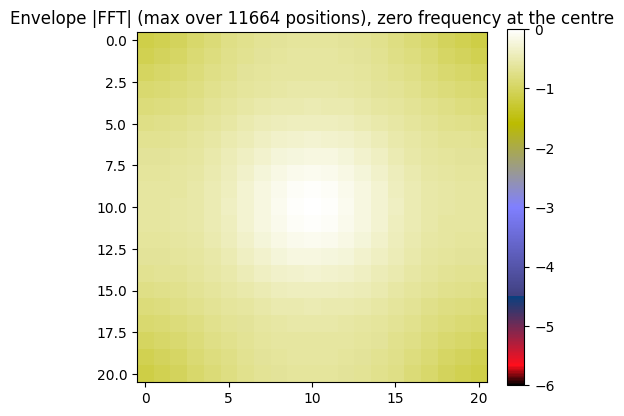

In [7]:
F_positions = np.fft.fft2(stamps, axes=(1, 2))          # (n_positions, 21, 21), complex
mag_positions = np.abs(F_positions)
mat_env_position = mag_positions.max(axis=0)             # envelope: pointwise max over all positions

print(f"Envelope (max over {n_positions} positions), FFT grid {mat_env_position.shape}")
plt.figure(figsize=(5, 5))
plt.imshow(safe_log10(np.fft.fftshift(mat_env_position) / mat_env_position.max()),
           cmap='gist_stern', vmax=0, vmin=-6)
plt.title('Envelope |FFT| (max over 11664 positions), zero frequency at the centre')
plt.colorbar(fraction=0.046)

## 7. Isotropisation by continuous rotation

Pointwise maximum of the envelope (zero frequency centred with `fftshift`) over 360 rotations of 1°
(`scipy.ndimage.rotate`). Rotations and maxima keep the central symmetry of the envelope, so it
remains the amplitude of a real image.

Positions no longer dominated after rotation: 0 / 11664


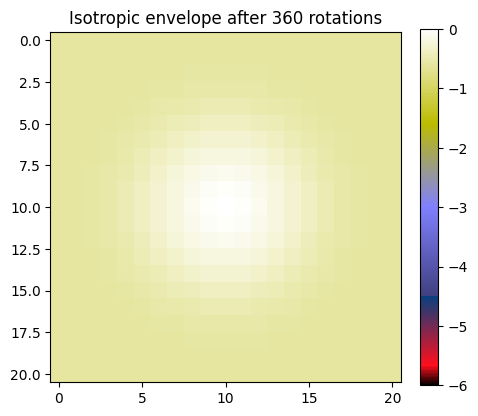

In [8]:
mat_env_shifted = np.fft.fftshift(mat_env_position)
mat_iso_shifted = mat_env_shifted.copy()
for angle in np.linspace(0, 360, n_rotation_steps, endpoint=False):
    rotated = ndi_rotate(mat_env_shifted, angle, reshape=False, order=1, mode='nearest')
    mat_iso_shifted = np.maximum(mat_iso_shifted, rotated)
mat_iso_fft = np.fft.ifftshift(mat_iso_shifted)   # back to the FFT convention (zero frequency in the corner)

n_viol = np.sum((mat_iso_fft[None, :, :] - mag_positions).reshape(n_positions, -1).min(axis=1) < -1e-9)
print(f"Positions no longer dominated after rotation: {n_viol} / {n_positions}")

plt.figure(figsize=(5, 5))
plt.imshow(safe_log10(np.fft.fftshift(mat_iso_fft) / mat_iso_fft.max()), cmap='gist_stern', vmax=0, vmin=-6)
plt.title(f"Isotropic envelope after {n_rotation_steps} rotations")
plt.colorbar(fraction=0.046)

## 8. Alternating projections: positivity and Fourier dominance

With a zero phase, the isotropic envelope gives an image with strong negative (Gibbs) rings, and
simply clipping them breaks the Fourier dominance. Instead, alternate:

1. **image space**: set negative pixels to 0 (a PSF is positive);
2. **Fourier space**: keep the phase and raise the amplitude to at least `mat_iso_fft`.

In [9]:
n_iterations = 2000
spectrum = mat_iso_fft.astype(np.complex128)   # start: zero phase
for _ in range(n_iterations):
    image_iter = np.fft.ifft2(spectrum).real
    image_iter = np.maximum(image_iter, 0.0)                     # positivity
    new_spectrum = np.fft.fft2(image_iter)
    magnitude_new = np.abs(new_spectrum)
    phase_new = np.angle(new_spectrum)
    magnitude_boosted = np.maximum(magnitude_new, mat_iso_fft)   # Fourier dominance
    spectrum = magnitude_boosted * np.exp(1j * phase_new)

image_projected = np.fft.ifft2(spectrum).real
print(f"After {n_iterations} iterations: "
      f"min={image_projected.min():.2e} (should be ~0), "
      f"residual fraction of negative pixels={np.mean(image_projected < -1e-8):.1e}")

After 2000 iterations: min=-5.93e-18 (should be ~0), residual fraction of negative pixels=0.0e+00


## 9. Final PSF: positivity, unit flux, checks

The final clip barely changes the image (positivity already holds to float precision). The final
PSF is then checked for FWHM ≤ smallest FWHM of the field and for Fourier dominance over all
positions.

Final FWHM: 0.1311" (smallest individual FWHM: 0.1415", <=: True)
Positions violating Fourier dominance (FFT): 48 / 11664, max deficit: -0.00149


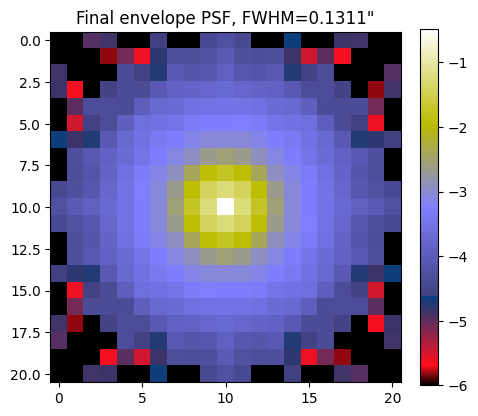

In [10]:
env_img_final = np.maximum(image_projected, 0.0)
env_img_final /= env_img_final.sum()
env_img_final = np.fft.fftshift(env_img_final)      # centre the PSF (image convention, like `stamps`)

effective_psf_check = galsim.InterpolatedImage(galsim.Image(env_img_final, scale=pixel_scale), flux=1.)
env_fwhm_final = effective_psf_check.calculateFWHM()

mag_final_fft = np.abs(np.fft.fft2(np.fft.ifftshift(env_img_final)))
deficits = (mag_final_fft[None, :, :] - mag_positions).reshape(n_positions, -1).min(axis=1)
n_viol_final = np.sum(deficits < -1e-9)

print(f"Final FWHM: {env_fwhm_final:.4f}\" (smallest individual FWHM: {fwhms.min():.4f}\", "
      f"<=: {env_fwhm_final <= fwhms.min()})")
print(f"Positions violating Fourier dominance (FFT): {n_viol_final} / {n_positions}, "
      f"max deficit: {deficits.min():.5f}")

plt.figure(figsize=(5, 5))
plt.imshow(safe_log10(env_img_final), cmap='gist_stern')
plt.title(f"Final envelope PSF, FWHM={env_fwhm_final:.4f}\"")
plt.colorbar(fraction=0.046)

## 10. Comparison with the sharpest PSF of the field

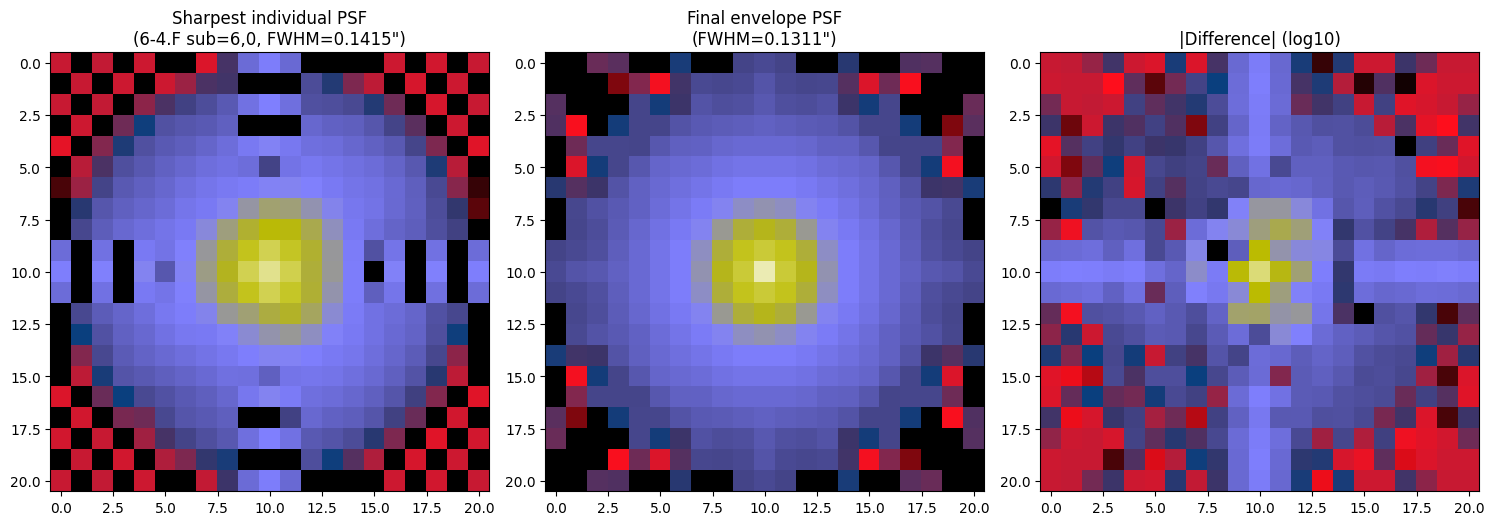

In [11]:
i_max = np.argmin(fwhms)
psf_max_img = galsim.InterpolatedImage(galsim.Image(stamps[i_max], scale=pixel_scale), flux=1.) \
    .drawImage(nx=output_stamp_size, ny=output_stamp_size, scale=pixel_scale).array

r_max = all_records[i_max]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(safe_log10(psf_max_img), cmap='gist_stern', vmin=-6, vmax=0)
axes[0].set_title(f"Sharpest individual PSF\n({r_max['name']} sub={r_max['sub_row']},"
                   f"{r_max['sub_col']}, FWHM={fwhms[i_max]:.4f}\")")
axes[1].imshow(safe_log10(env_img_final), cmap='gist_stern', vmin=-6, vmax=0)
axes[1].set_title(f"Final envelope PSF\n(FWHM={env_fwhm_final:.4f}\")")
axes[2].imshow(safe_log10(np.abs(psf_max_img - env_img_final)), cmap='gist_stern', vmin=-6, vmax=0)
axes[2].set_title('|Difference| (log10)')
plt.tight_layout()

## 11. Save the PSF (FITS)

Envelope PSF saved: ./euclid_vis_isotropic_min_psf.fits (shape (21, 21), pixel_scale=0.1 arcsec/pixel)


Text(0.5, 1.0, 'Isotropic envelope PSF (saved)')

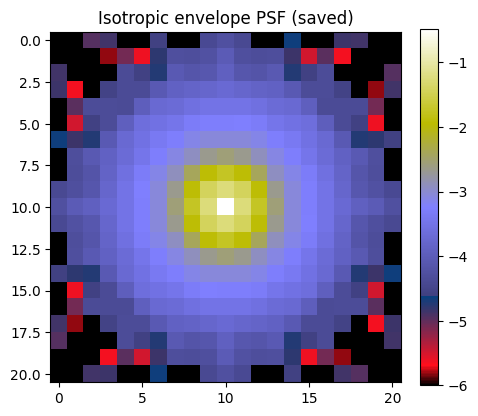

In [12]:
env_out_path = f'{output_dir}/euclid_vis_isotropic_min_psf.fits'
fits.writeto(env_out_path, env_img_final.astype(np.float32), overwrite=True)
print(f"Envelope PSF saved: {env_out_path} (shape {env_img_final.shape}, "
      f"pixel_scale={pixel_scale} arcsec/pixel)")

plt.figure(figsize=(5, 5))
plt.imshow(safe_log10(env_img_final), cmap='gist_stern')
plt.colorbar(fraction=0.046)
plt.title('Isotropic envelope PSF (saved)')

## 12. Independent check with the GalSim Fourier transform

Step 9 checks the result with the same FFT as the construction. This repeats the dominance and FWHM
checks with the continuous GalSim transform of step 5 (`ims_k`), to rule out an artefact of the
discrete FFT.

Fourier dominance of the saved PSF (GalSim transform):
  positions in violation: 48 / 11664
  max deficit (most negative, relative to a peak of ~1): -0.00149
  FWHM of the saved PSF: 0.1311", smallest individual FWHM: 0.1415" (<=: True)


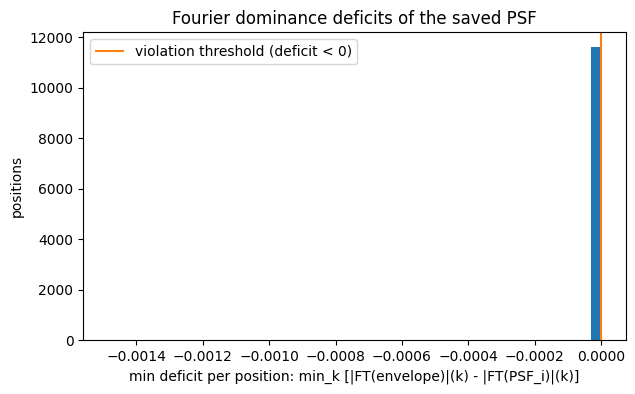

In [13]:
# GalSim FT of the saved PSF, on the same k grid as ims_k
saved_psf = galsim.InterpolatedImage(galsim.Image(env_img_final, scale=pixel_scale), flux=1.)
mat_saved_k = np.abs(saved_psf.drawKImage(nx=stamp_size, ny=stamp_size, scale=kscale).array)

deficits = np.array([(mat_saved_k - ims_k[i]).min() for i in range(n_positions)])
n_violations = int(np.sum(deficits < -1e-9))
saved_fwhm = saved_psf.calculateFWHM()

print("Fourier dominance of the saved PSF (GalSim transform):")
print(f"  positions in violation: {n_violations} / {n_positions}")
print(f"  max deficit (most negative, relative to a peak of ~1): {deficits.min():.5f}")
print(f"  FWHM of the saved PSF: {saved_fwhm:.4f}\", smallest individual FWHM: "
      f"{fwhms.min():.4f}\" (<=: {saved_fwhm <= fwhms.min()})")

plt.figure(figsize=(7, 4))
plt.hist(deficits, bins=50)
plt.axvline(0, color='C1', lw=1.5, label='violation threshold (deficit < 0)')
plt.xlabel('min deficit per position: min_k [|FT(envelope)|(k) - |FT(PSF_i)|(k)]')
plt.ylabel('positions')
plt.title('Fourier dominance deficits of the saved PSF')
plt.legend()

## 13. Residual kernels by Fourier division

For a few positions: `kernel_i = FT(PSF_i) / FT(reference)` (what the `psf_residual` column holds),
then `reference ⊛ kernel_i`. This reconstruction is exact by construction as long as
`FT(reference)` never vanishes, so its residual only shows float precision. What matters is the
stability of the division:

1. `|FT(reference)|` stays far from 0;
2. `|kernel_i(k)|` stays bounded (close to 1 at most);
3. the kernel is compact in image space, with few negative values and a flux close to 1.

Stability of the base: min |FT(envelope)| = 0.2497 (far from 0: safe division), max residual imaginary part = 3.9e-14 (should be ~0)



[sharpest (min FWHM)] position #10827 (FWHM=0.1415"): max |kernel| in Fourier=1.0000, kernel min in image=-2.67e-02, kernel flux=1.0000, max residual |initial-reconvolution|=5.55e-17
[widest (max FWHM)] position #0 (FWHM=0.1572"): max |kernel| in Fourier=1.0000, kernel min in image=-3.91e-02, kernel flux=1.0000, max residual |initial-reconvolution|=5.55e-17
[largest dominance deficit] position #5840 (FWHM=0.1477"): max |kernel| in Fourier=1.0016, kernel min in image=-5.55e-02, kernel flux=1.0000, max residual |initial-reconvolution|=5.55e-17
[random position] position #2732 (FWHM=0.1498"): max |kernel| in Fourier=1.0000, kernel min in image=-4.64e-02, kernel flux=1.0000, max residual |initial-reconvolution|=1.11e-16


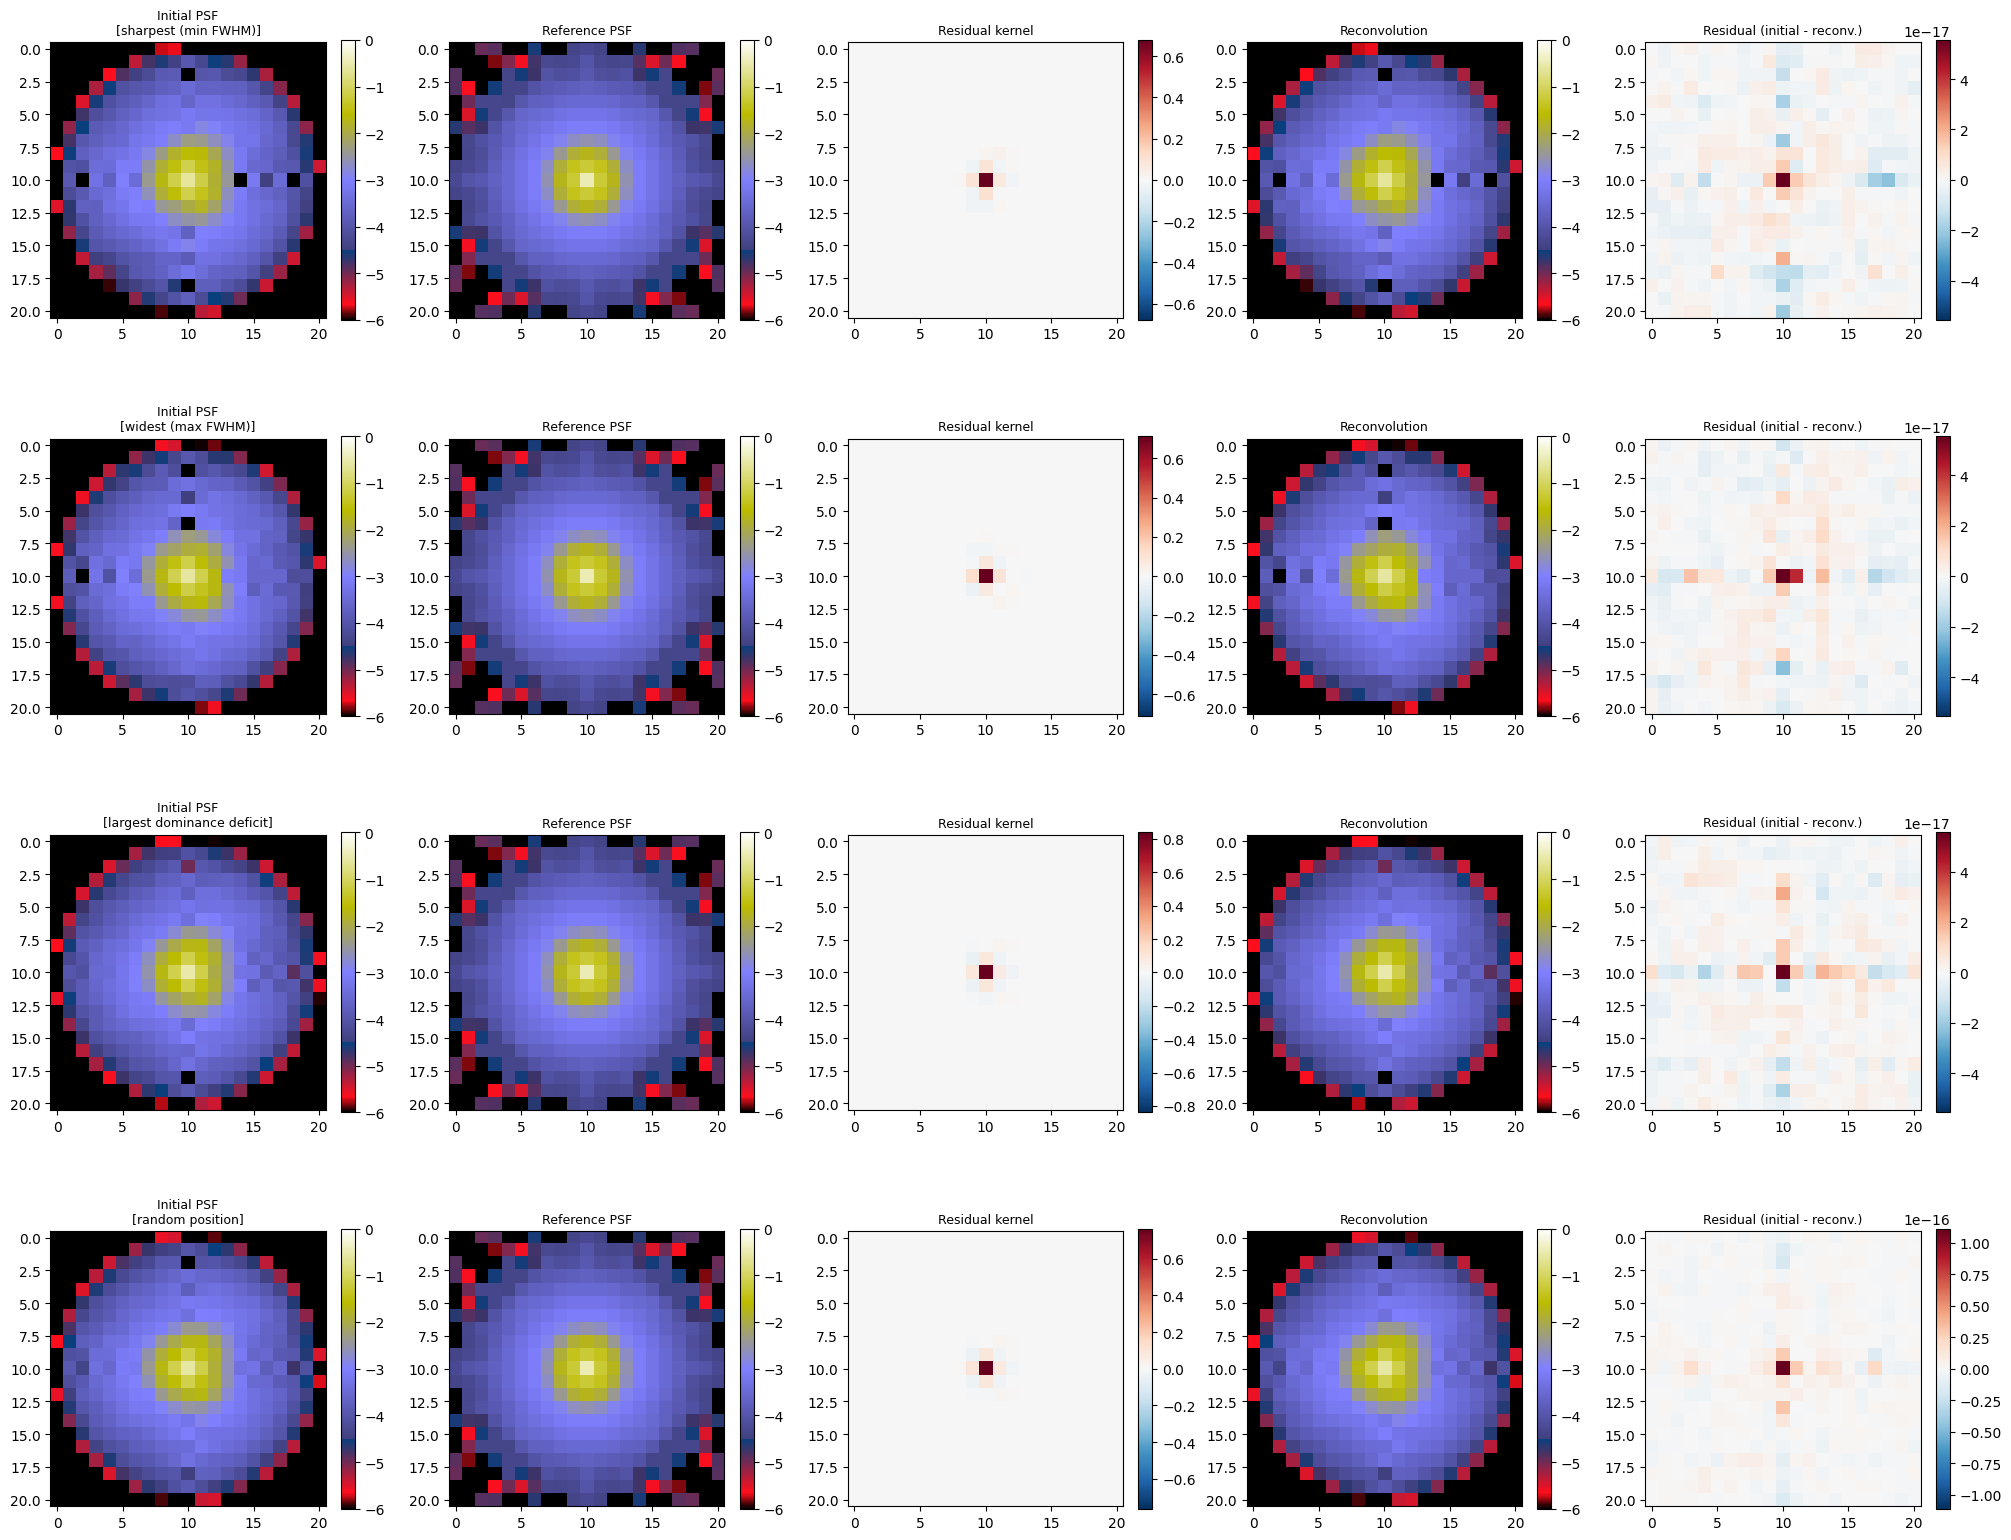

In [14]:
example_indices = {
    "sharpest (min FWHM)": int(np.argmin(fwhms)),
    "widest (max FWHM)": int(np.argmax(fwhms)),
    "largest dominance deficit": int(np.argmin(deficits)),
    "random position": int(np.random.RandomState(0).randint(n_positions)),
}

# FT of the envelope, same (unshifted) convention as F_positions
base_fft = np.fft.fft2(np.fft.ifftshift(env_img_final))
print(f"Stability of the base: min |FT(envelope)| = {np.abs(base_fft).min():.4f} "
      f"(far from 0: safe division), "
      f"max residual imaginary part = {np.abs(base_fft.imag).max():.1e} (should be ~0)\n")

fig, axes = plt.subplots(len(example_indices), 5, figsize=(20, 4 * len(example_indices)))
for row, (label, i) in enumerate(example_indices.items()):
    psf_i = stamps[i]
    psf_i_fft = F_positions[i]

    kernel_fft = psf_i_fft / base_fft
    kernel_mag = np.abs(kernel_fft)
    kernel_img = np.fft.ifft2(kernel_fft).real   # already centred like stamps[i]

    recon_fft = base_fft * kernel_fft
    recon_img = np.fft.ifft2(recon_fft).real

    residual_img = psf_i - recon_img

    print(f"[{label}] position #{i} (FWHM={fwhms[i]:.4f}\"): "
          f"max |kernel| in Fourier={kernel_mag.max():.4f}, "
          f"kernel min in image={kernel_img.min():.2e}, kernel flux={kernel_img.sum():.4f}, "
          f"max residual |initial-reconvolution|={np.abs(residual_img).max():.2e}")

    panels = [
        ("Initial PSF", psf_i, True),
        ("Reference PSF", env_img_final, True),
        ("Residual kernel", kernel_img, False),
        ("Reconvolution", recon_img, True),
        ("Residual (initial - reconv.)", residual_img, False),
    ]
    for col, (title, img, is_flux) in enumerate(panels):
        ax = axes[row, col]
        if is_flux:
            im = ax.imshow(safe_log10(img), cmap='gist_stern', vmin=-6, vmax=0)
        else:
            vmax = np.abs(img).max()
            im = ax.imshow(img, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(f"{title}\n[{label}]" if col == 0 else title, fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

## 14. Residual anisotropy of the final PSF

Step 8 does not exactly preserve the isotropy of step 7: the positivity clip is only invariant
under rotations by multiples of 90°, and raising the amplitude never lowers it back. Two checks:

1. **image space**: maximum deviation of the PSF under 360 rotations of 1°;
2. **Fourier space**: angular coefficient of variation of `|FT|` in each `|k|` ring
   (0 = perfectly isotropic).

Max image-space deviation over 360 rotations: 1.477e-02 (PSF peak = 3.314e-01, ratio = 4.46%)
Angular coefficient of variation of |FT|: mean=0.0382, max=0.1086


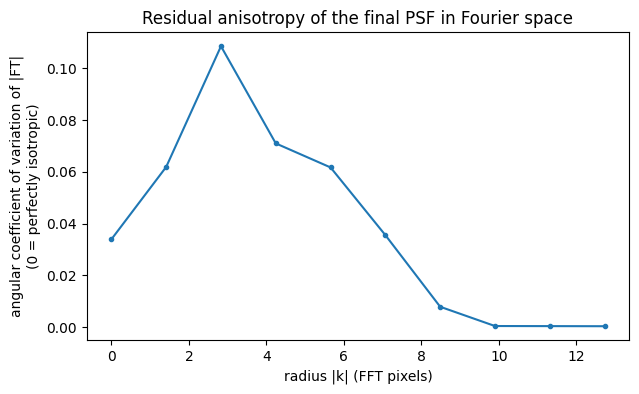

In [15]:
# Test 1: image space, sensitivity to continuous rotation
angles_test = np.linspace(0, 360, n_rotation_steps, endpoint=False)
rotated_diffs = np.array([
    np.abs(ndi_rotate(env_img_final, a, reshape=False, order=1, mode='nearest') - env_img_final).max()
    for a in angles_test
])
print(f"Max image-space deviation over {n_rotation_steps} rotations: {rotated_diffs.max():.3e} "
      f"(PSF peak = {env_img_final.max():.3e}, ratio = {rotated_diffs.max() / env_img_final.max():.2%})")

# Test 2: Fourier space, angular spread of |FT| in each frequency ring
mag_final = np.fft.fftshift(np.abs(np.fft.fft2(np.fft.ifftshift(env_img_final))))
cy, cx = (stamp_size - 1) / 2, (stamp_size - 1) / 2
yy, xx = np.mgrid[0:stamp_size, 0:stamp_size]
kr = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
n_bins = stamp_size // 2
bin_edges = np.linspace(0, kr.max(), n_bins + 1)
bin_idx = np.digitize(kr.ravel(), bin_edges) - 1

cv_per_bin = np.full(n_bins, np.nan)
for b in range(n_bins):
    vals = mag_final.ravel()[bin_idx == b]
    if vals.size > 4 and vals.mean() > 0:
        cv_per_bin[b] = vals.std() / vals.mean()

plt.figure(figsize=(7, 4))
plt.plot(bin_edges[:-1], cv_per_bin, marker='o', ms=3)
plt.xlabel('radius |k| (FFT pixels)')
plt.ylabel("angular coefficient of variation of |FT|\n(0 = perfectly isotropic)")
plt.title("Residual anisotropy of the final PSF in Fourier space")

print(f"Angular coefficient of variation of |FT|: mean={np.nanmean(cv_per_bin):.4f}, "
      f"max={np.nanmax(cv_per_bin):.4f}")